In [20]:
import datetime
print(f"Last updated on {datetime.date.today()}.")

Last updated on 2026-03-11.


# Direct inversion algorithm for reference state computation (Neal et al 2023 GRL)

This notebook is using a dataset of $1.0^\circ\times1.0^\circ$ grid resolution such that `eq_boundary_index=5` refers to an equatorward boundary at $5^\circ$N.

---

Please [raise an issue in the GitHub repo](https://github.com/csyhuang/hn2016_falwa/issues) or contact Clare S. Y. Huang (csyhuang@uchicago.edu) if you have any questions or suggestions regarding the package.

In [21]:
import numpy as np
import xarray as xr
from numpy import dtype
from math import pi
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import datetime as dt
%matplotlib inline
from falwa.oopinterface import QGFieldNHN22
import datetime as dt
import falwa
print(falwa.__version__)

2.3.2


## Load ERA5 data from Jiacheng's attachment

In [ ]:
u_file = xr.open_dataset('era5_1986_09_uvt_t48_51.nc')
v_file = xr.open_dataset('era5_1986_09_uvt_t48_51.nc')
t_file = xr.open_dataset('era5_1986_09_uvt_t48_51.nc')
ntimes = u_file.time.size
time_array = u_file.time


In [22]:
path_example = "/nas/jiachengye/falwa/falwa_ticket_issue/"
#uvt_file = xr.open_dataset(path_example+'era5_1986_09_uvt_t48_51.nc') # One only needs to change this line to read data. 
u_file = xr.open_dataset(path_example+'era5_1986_09_uvt_t48_51.nc')
v_file = xr.open_dataset(path_example+'era5_1986_09_uvt_t48_51.nc')
t_file = xr.open_dataset(path_example+'era5_1986_09_uvt_t48_51.nc')
ntimes = u_file.time.size
time_array = u_file.time


In [23]:
u_file

<xarray.Dataset>
Dimensions:    (time: 4, level: 37, latitude: 181, longitude: 360)
Coordinates:
  * longitude  (longitude) float32 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * latitude   (latitude) float32 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * level      (level) int32 1 2 3 5 7 10 20 30 ... 850 875 900 925 950 975 1000
  * time       (time) datetime64[ns] 1986-09-13 ... 1986-09-13T18:00:00
Data variables:
    u          (time, level, latitude, longitude) float32 ...
    v          (time, level, latitude, longitude) float32 ...
    t          (time, level, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2021-08-07 15:15:52 GMT by grib_to_netcdf-2.20.0: /opt/ecmw...

## Load the dimension arrays
In this version, the `QGField` object takes only:
- latitude array in degree ascending order, and 
- pressure level in hPa in decending order (from ground to aloft).

In [24]:
xlon = u_file.longitude.values

# latitude has to be in ascending order
ylat = u_file.latitude.values
if np.diff(ylat)[0]<0:
    print('Flip ylat.')
    ylat = ylat[::-1]

# pressure level has to be in descending order (ascending height)
plev = u_file.level.values
if np.diff(plev)[0]>0:
    print('Flip plev.')    
    plev = plev[::-1]

nlon = xlon.size
nlat = ylat.size
nlev = plev.size

Flip ylat.
Flip plev.


In [25]:
clat = np.cos(np.deg2rad(ylat))     # cosine latitude
p0 = 1000.                          # surface pressure [hPa]
kmax = 49                           # number of grid points for vertical extrapolation (dimension of height)
dz = 1000.                          # differential height element
height = np.arange(0,kmax)*dz       # pseudoheight [m]
dphi = np.diff(ylat)[0]*pi/180.     # differential latitudinal element
dlambda = np.diff(xlon)[0]*pi/180.  # differential latitudinal element
hh = 7000.                          # scale height
cp = 1004.                          # heat capacity of dry air
rr = 287.                           # gas constant
omega = 7.29e-5                     # rotation rate of the earth
aa = 6.378e+6                       # earth radius
prefactor = np.array([np.exp(-z/hh) for z in height[1:]]).sum() # integrated sum of density from the level
                                                                #just above the ground (z=1km) to aloft
npart = nlat                        # number of partitions to construct the equivalent latitude grids
maxits = 100000                     # maximum number of iteration in the SOR solver to solve for reference state
tol = 1.e-5                         # tolerance that define convergence of solution
rjac = 0.95                         # spectral radius of the Jacobi iteration in the SOR solver.              
jd = nlat//2+1                      # (one plus) index of latitude grid point with value 0 deg
                                    # This is to be input to fortran code. The index convention is different.

## Set the level of pressure and the timestamp to display below

In [28]:
tstamp = [dt.datetime(1986,9,13,0,0) + dt.timedelta(seconds=6*3600) * tt for tt in range(ntimes)]
plev_selected = 1 # selected pressure level to display
tstep_selected = 1

## Additional parameters to compute reference state from NHN22 boundary conditions

This dataset has $1.0^\circ$ latitude resolution. `eq_boundary_index = 5` refers to an equatorward boundary at $5^\circ$N

In [29]:
eq_boundary_index = 5

## Loop through the input file and store all the computed quantities in a netCDF file

Do scipy interpolation
 nlon, nlat, kmax, jd
         360         181          49          91
num of nan in fawa: 13.
line 748: ncforce is None
 nd:           91 , jb:            5
 nd:           91 , jb:            5
 nd:           91 , jb:            5
 nd:           91 , jb:            5


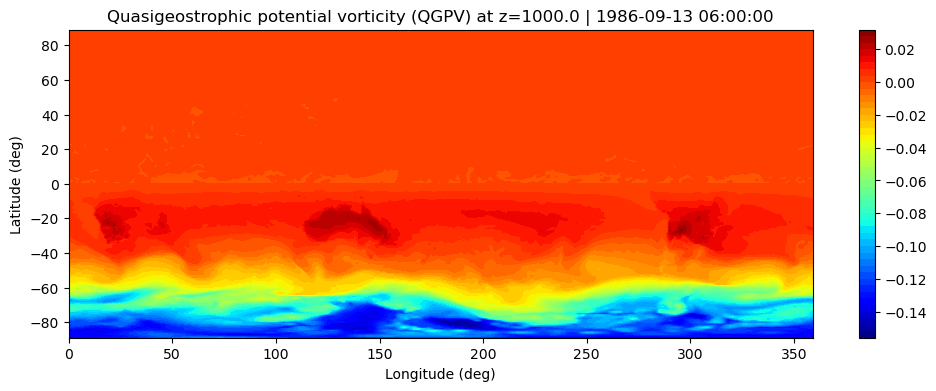

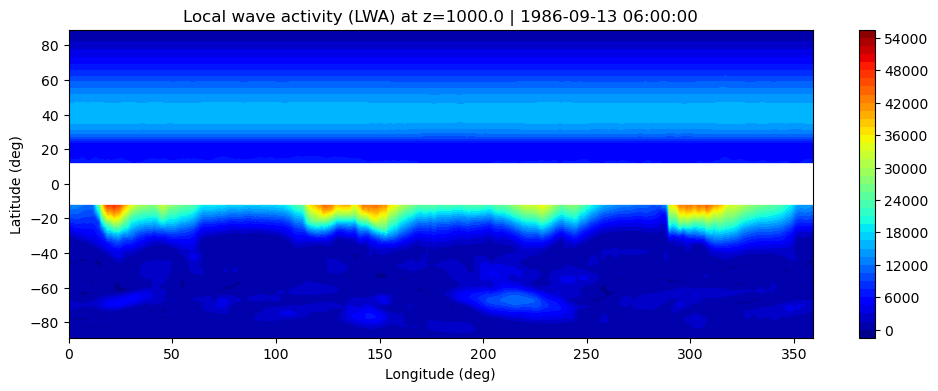

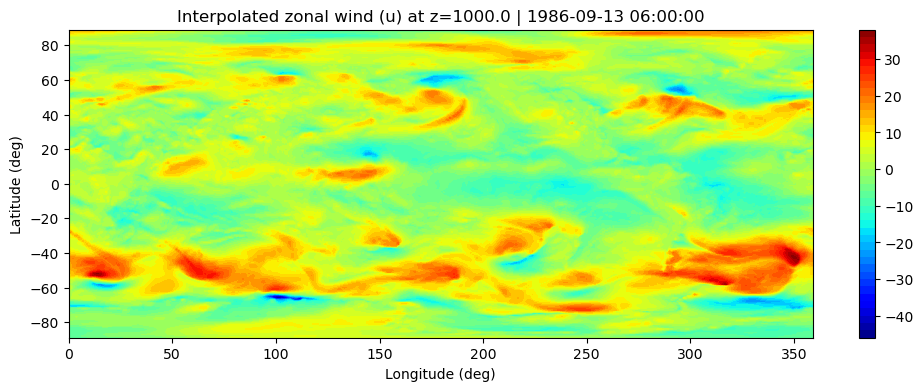

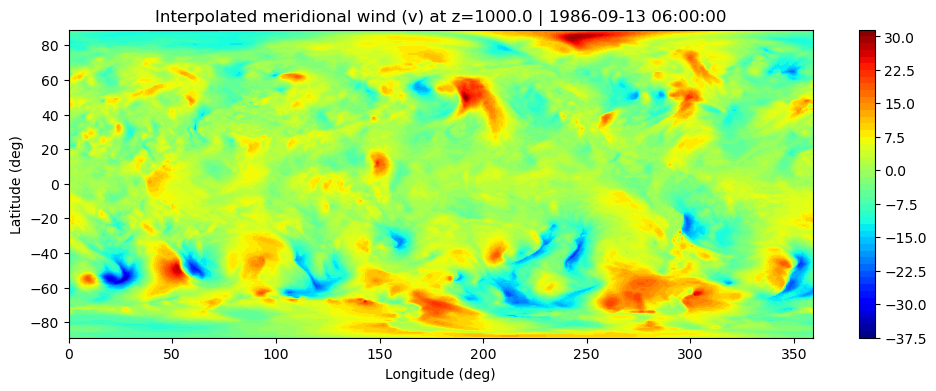

Max(val):0.027801693768329513, Min(val):-0.1506494651536587


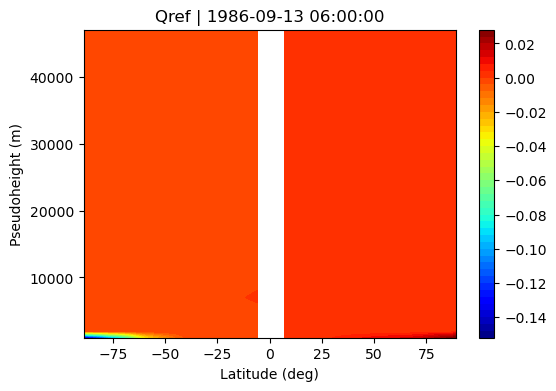

Max(val):318.535400390625, Min(val):-109.73371887207031


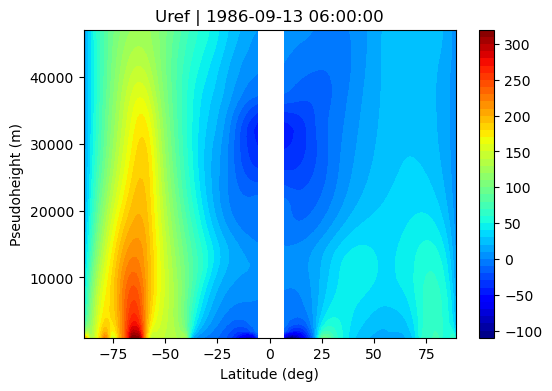

Max(val):1845.8309326171875, Min(val):-1136.6087646484375


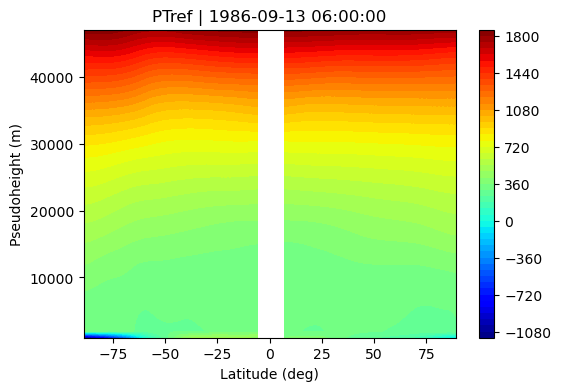

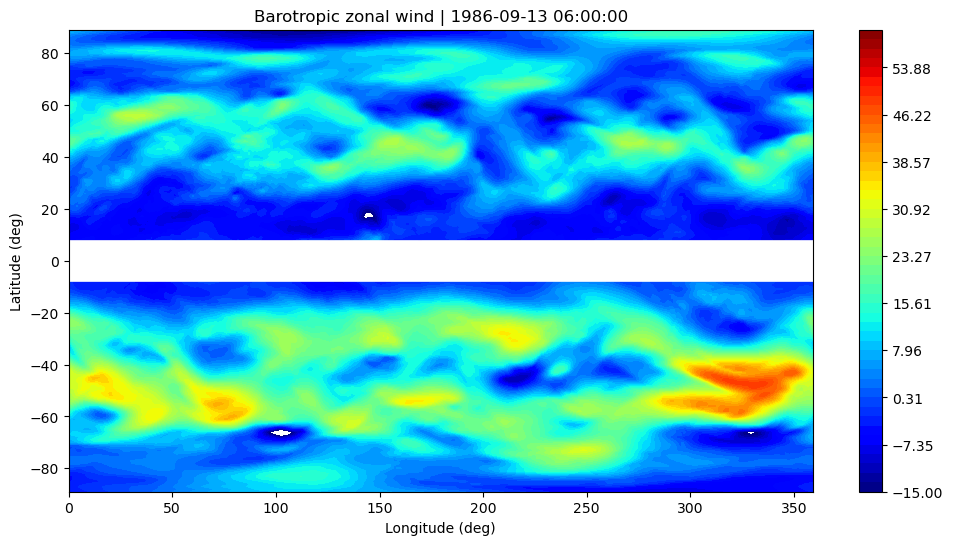

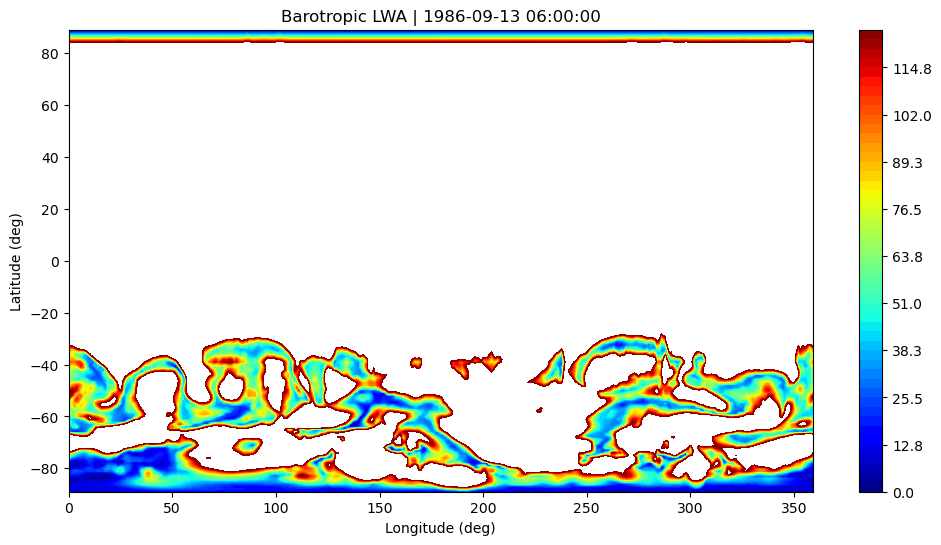

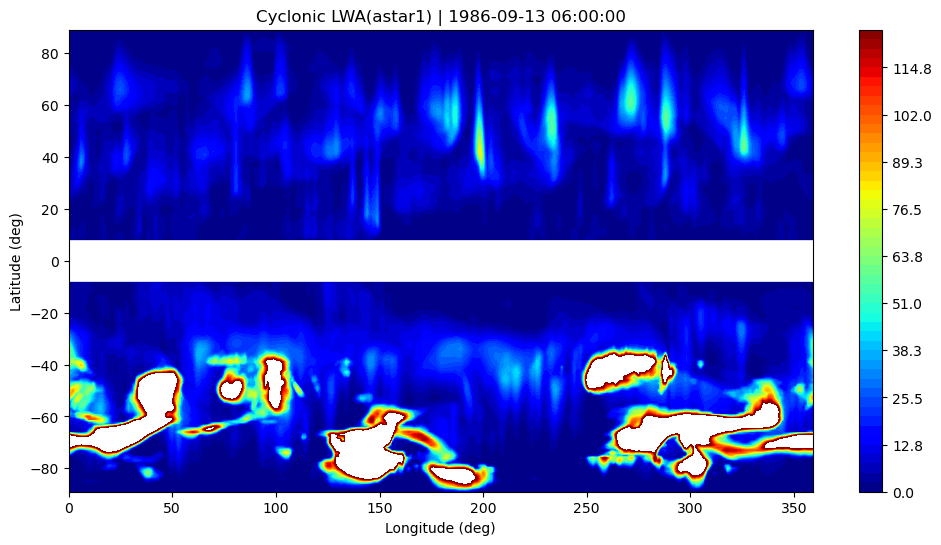

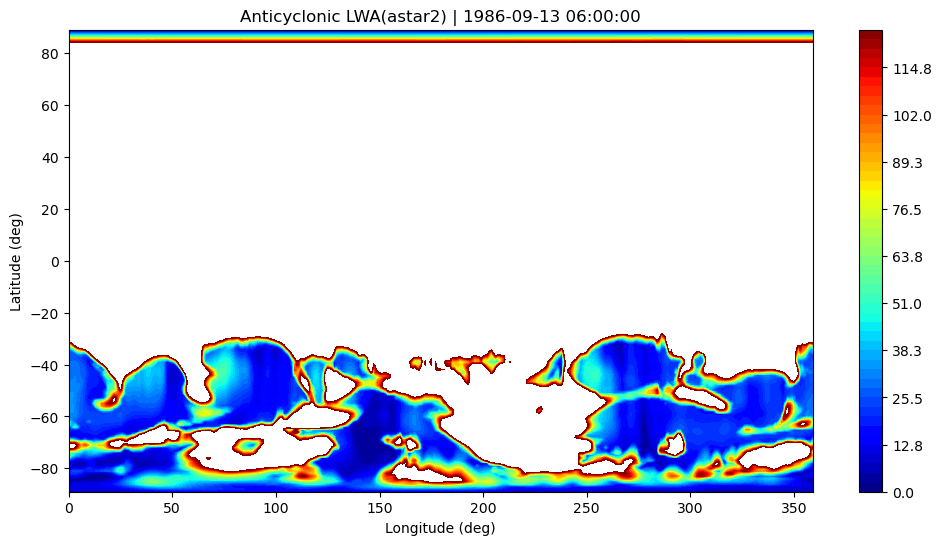

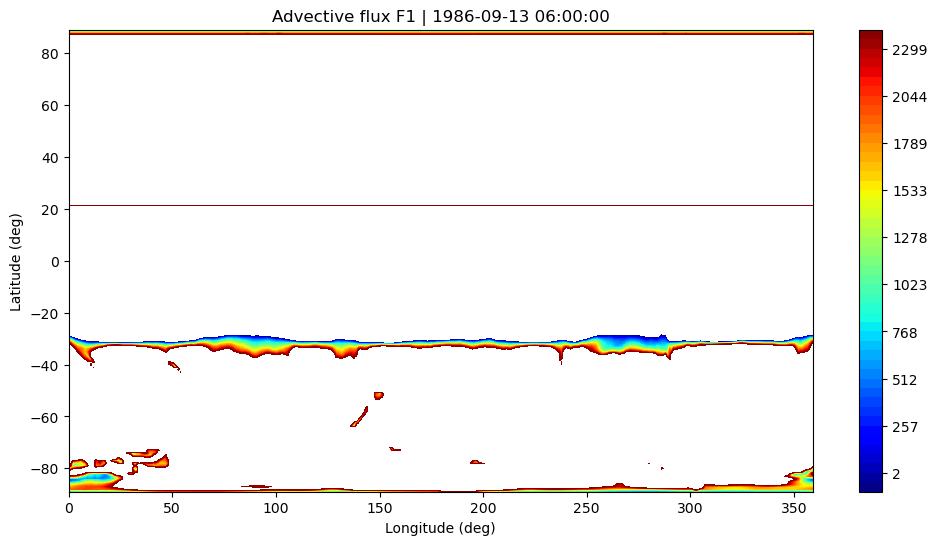

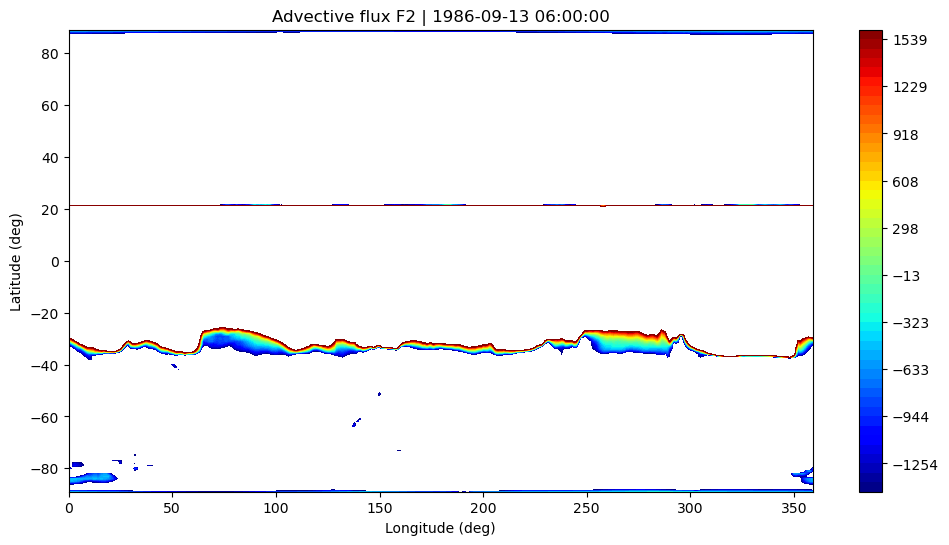

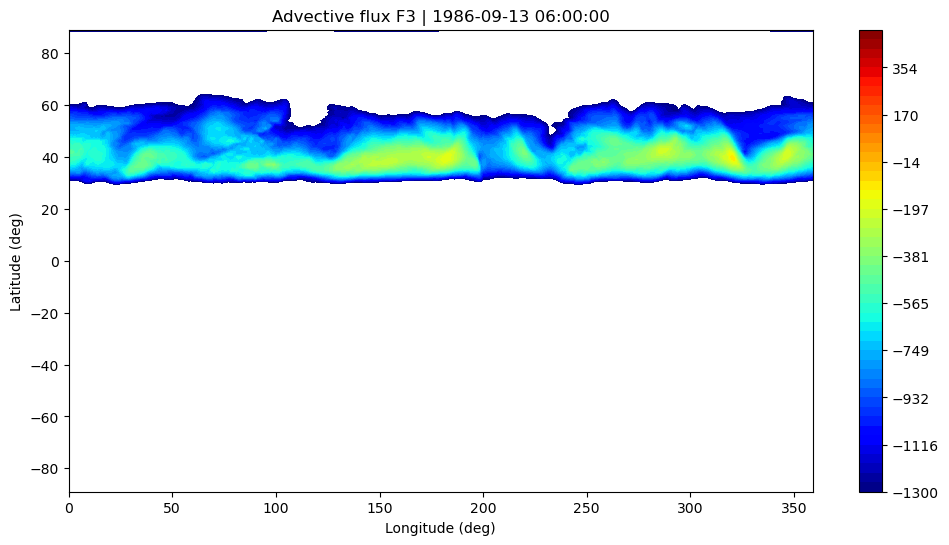

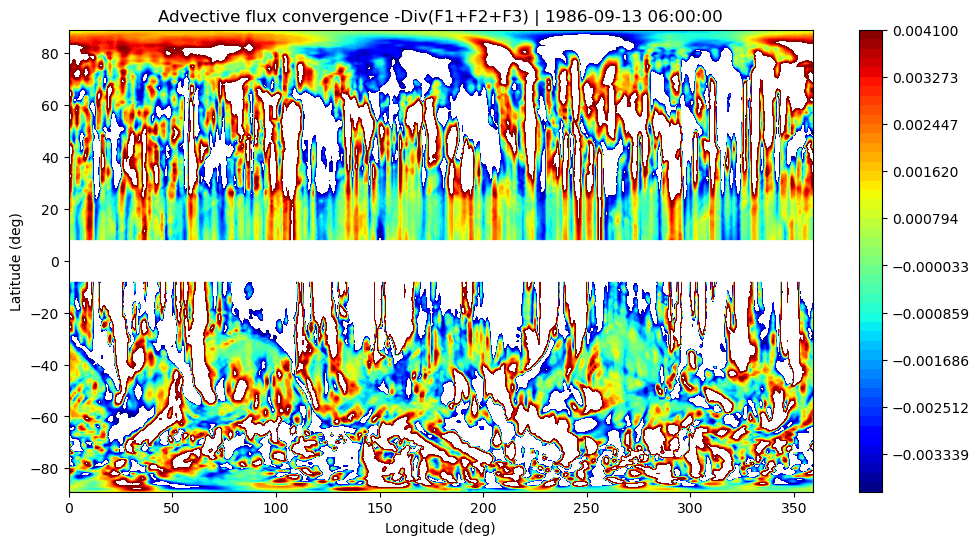

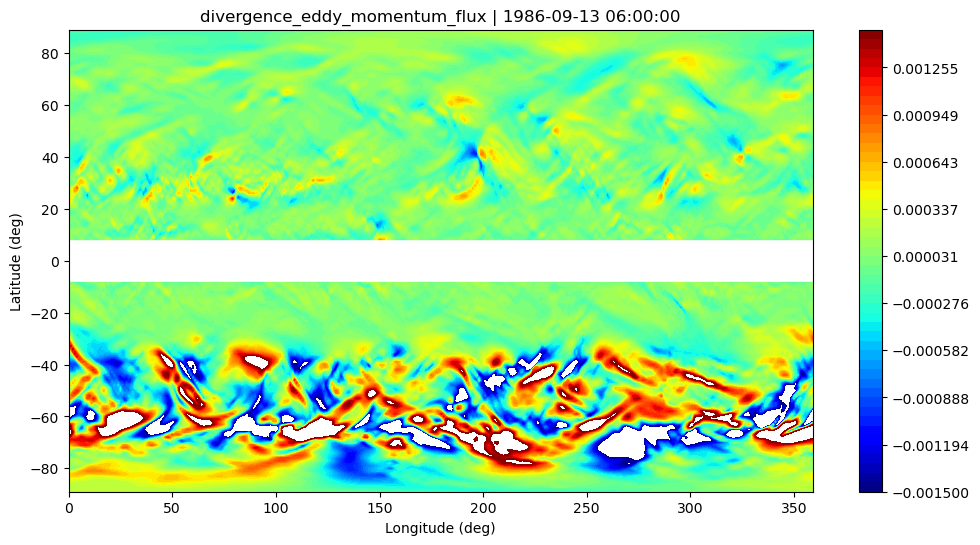

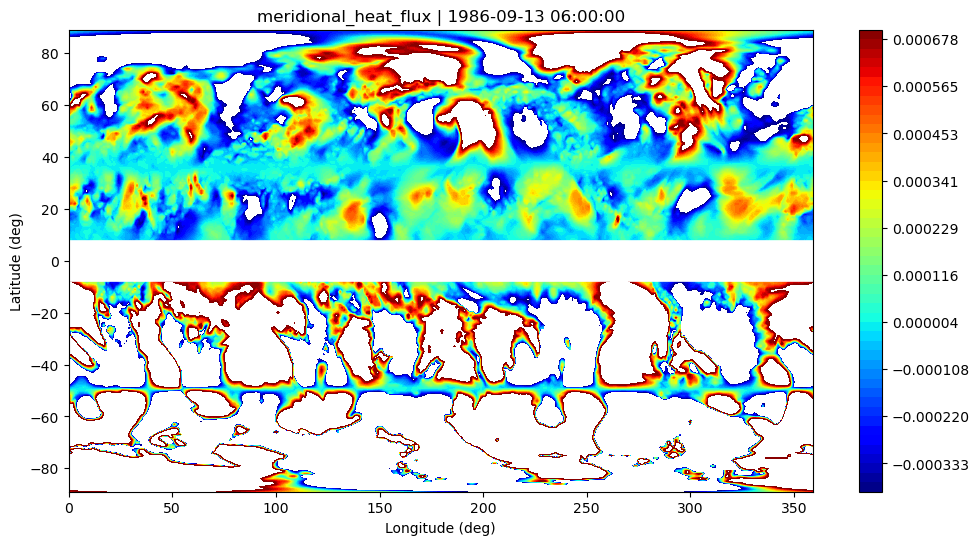

In [30]:
tstep=tstep_selected
uu = u_file.variables['u'][tstep, ::-1, ::-1, :].data
vv = v_file.variables['v'][tstep, ::-1, ::-1, :].data
tt = t_file.variables['t'][tstep, ::-1, ::-1, :].data

qgfield_object = QGFieldNHN22(
    xlon, ylat, plev, uu, vv, tt, eq_boundary_index=eq_boundary_index, northern_hemisphere_results_only=False)
equator_idx = qgfield_object.equator_idx

qgfield_object.interpolate_fields(return_named_tuple=False)

qgfield_object.compute_reference_states(return_named_tuple=False)

qgfield_object.compute_lwa_and_barotropic_fluxes(return_named_tuple=False)

qgfield_object.compute_layerwise_lwa_fluxes()


# === Below demonstrate another way to access the computed variables ===
# 3D Variables that I would choose one pressure level to display
variables_3d = [
    (qgfield_object.qgpv, 'Quasigeostrophic potential vorticity (QGPV)'),
    (qgfield_object.lwa, 'Local wave activity (LWA)'),
    (qgfield_object.interpolated_u, 'Interpolated zonal wind (u)'),
    (qgfield_object.interpolated_v, 'Interpolated meridional wind (v)')]

# Reference states to be displayed on y-z plane
variables_yz = [
    (qgfield_object.qref, 'Qref'),
    (qgfield_object.uref, 'Uref'),
    (qgfield_object.ptref, 'PTref')]

# Vertically averaged variables to be displayed on x-y plane
variables_xy = [
    (qgfield_object.u_baro, 'Barotropic zonal wind'),
    (qgfield_object.lwa_baro, 'Barotropic LWA'),
    (np.swapaxes(qgfield_object._barotropic_flux_terms_storage.astar1_baro, 1, 0), 'Cyclonic LWA(astar1)'),
    (np.swapaxes(qgfield_object._barotropic_flux_terms_storage.astar2_baro, 1, 0), 'Anticyclonic LWA(astar2)'),
    (qgfield_object.adv_flux_f1, 'Advective flux F1'),
    (qgfield_object.adv_flux_f2, 'Advective flux F2'),
    (qgfield_object.adv_flux_f3, 'Advective flux F3'),
    (qgfield_object.convergence_zonal_advective_flux, 'Advective flux convergence -Div(F1+F2+F3)'),
    (qgfield_object.divergence_eddy_momentum_flux, 'divergence_eddy_momentum_flux'),
    (qgfield_object.meridional_heat_flux, 'meridional_heat_flux')
]

# Plot 240 hPa of 3D-variables
for variable, name in variables_3d:
    plt.figure(figsize=(12,4))
    plt.contourf(xlon, ylat[1:-1], variable[plev_selected, 1:-1, :], 50, cmap='jet')
    if name=='Local wave activity (LWA)':
        plt.axhline(y=0, c='w', lw=30)
    plt.colorbar()
    plt.ylabel('Latitude (deg)')
    plt.xlabel('Longitude (deg)')
    plt.title(f'{name} at z={height[plev_selected]} | {str(tstamp[tstep])}')
    plt.show()

# Plot reference states
for variable, name in variables_yz:
    # Mask out equatorward region that is outside analysis boundary
    mask = np.zeros_like(variable)
    mask[:, equator_idx-eq_boundary_index-1:equator_idx+eq_boundary_index+1] = np.nan
    variable_masked = np.ma.array(variable, mask=mask)
    # Start plotting
    print(f"Max(val):{variable_masked[1:-1, 1:-1].max()}, Min(val):{variable_masked[1:-1, 1:-1].min()}")
    plt.figure(figsize=(6,4))
    plt.contourf(ylat[1:-1], height[1:-1], variable_masked[1:-1, 1:-1], 50, cmap='jet')
    plt.axvline(x=0, c='w', lw=2)
    plt.xlabel('Latitude (deg)')
    plt.ylabel('Pseudoheight (m)')
    plt.colorbar()
    plt.title(name + ' | ' + str(tstamp[tstep]))
    plt.show()

# Plot fluxes (color axies have to be fixed)
plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[0][0][1:-1, :], np.linspace(-15, 60, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[0][1] + ' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[1][0][1:-1, :], np.linspace(0, 125, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[1][1] + ' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[2][0][1:-1, :], np.linspace(0, 125, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[2][1] + ' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[3][0][1:-1, :], np.linspace(0, 125, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[3][1] + ' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[4][0][1:-1, :], np.linspace(-100, 2401, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[4][1] + ' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[5][0][1:-1, :], np.linspace(-1440, 1601, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[5][1] + ' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[6][0][1:-1, :], np.linspace(-1300, 501, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[6][1] + ' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[7][0][1:-1, :], np.linspace(-0.004, 0.0041, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[7][1] +' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[8][0][1:-1, :], np.linspace(-0.0015, 0.0015, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[8][1] +' | ' + str(tstamp[tstep]))
plt.show()

plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[1:-1], variables_xy[9][0][1:-1, :], np.linspace(-0.0004, 0.0007, 50), cmap='jet')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
plt.title(variables_xy[9][1] +' | ' + str(tstamp[tstep]))
plt.show()


The following cells investigate the source of the QGPV blow-up issue.
 In particular, each variable in the stretching term—originally computed
using the NHN22 method implemented in:
 https://github.com/csyhuang/hn2016_falwa/blob/chuang-check-case-from-jiacheng/src/falwa/f90_modules/compute_qgpv_direct_inv.f90

is replaced with the corresponding variable calculated following the
NH18 implementation documented in:
https://github.com/csyhuang/hn2016_falwa/blob/chuang-check-case-from-jiacheng/src/falwa/f90_modules/compute_qgpv.f90


The Python code implemented here relies on multiple loops and is not optimized
for computational efficiency, but it is sufficient for diagnosing the source
of the error.

In [31]:
# Please see line 131 to 160 for the key part of the QGPV calculation and comparison between NH18 and NHN22 implementations.
u = qgfield_object.interpolated_u.copy()         # (49, 181, 360)
v = qgfield_object.interpolated_v.copy()         # (49, 181, 360)
theta = qgfield_object.interpolated_theta.copy() # (49, 181, 360)

kmax, nlat, nlon = u.shape

height = np.arange(kmax) * 1000.0

# same slicing idea as source:
# self._jd = nlat//2 + nlat%2 - eq_boundary_index
jd_bg = nlat // 2 + nlat % 2 - eq_boundary_index   # 86 for nlat=181, eq_boundary_index=5
lat_rad = np.deg2rad(ylat)
csm = clat[:jd_bg].sum()

# southern hemisphere mean profile, excluding equatorial buffer
t0_s = (
    np.mean(theta[:, :jd_bg, :] * clat[np.newaxis, :jd_bg, np.newaxis], axis=2)
    .sum(axis=1) / csm
)

# northern hemisphere mean profile, excluding equatorial buffer
t0_n = (
    np.mean(theta[:, -jd_bg:, :] * clat[np.newaxis, -jd_bg:, np.newaxis], axis=2)
    .sum(axis=1) / csm
)

stat_s = qgfield_object.static_stability[0].copy()  # (49,)
stat_n = qgfield_object.static_stability[1].copy()  # (49,)
# NH18 uses global mean background profiles
t0_18 = 0.5 * (t0_s + t0_n)
stat_18 = 0.5 * (stat_s + stat_n)

# --------------------------------------------------
# 2) common absolute vorticity
#    this part is effectively the same in NH18 and NHN22
# --------------------------------------------------
avort = np.zeros((kmax, nlat, nlon), dtype=np.float64)

for k in range(kmax):
    for j in range(1, nlat - 1):
        phi0 = lat_rad[j]
        phim = lat_rad[j - 1]
        phip = lat_rad[j + 1]

        for i in range(1, nlon - 1):
            av1 = 2.0 * omega * np.sin(phi0)
            av2 = (v[k, j, i + 1] - v[k, j, i - 1]) / (2.0 * aa * np.cos(phi0) * dphi)
            av3 = -(u[k, j + 1, i] * np.cos(phip) - u[k, j - 1, i] * np.cos(phim)) / (2.0 * aa * np.cos(phi0) * dphi)
            avort[k, j, i] = av1 + av2 + av3

        # i = 0
        av1 = 2.0 * omega * np.sin(phi0)
        av2 = (v[k, j, 1] - v[k, j, -1]) / (2.0 * aa * np.cos(phi0) * dphi)
        av3 = -(u[k, j + 1, 0] * np.cos(phip) - u[k, j - 1, 0] * np.cos(phim)) / (2.0 * aa * np.cos(phi0) * dphi)
        avort[k, j, 0] = av1 + av2 + av3

        # i = nlon-1
        av4 = 2.0 * omega * np.sin(phi0)
        av5 = (v[k, j, 0] - v[k, j, -2]) / (2.0 * aa * np.cos(phi0) * dphi)
        av6 = -(u[k, j + 1, -1] * np.cos(phip) - u[k, j - 1, -1] * np.cos(phim)) / (2.0 * aa * np.cos(phi0) * dphi)
        avort[k, j, -1] = av4 + av5 + av6

    # pole treatment: set pole row to zonal mean of nearest interior latitude
    avs = avort[k, 1, :].mean()
    avn = avort[k, -2, :].mean()
    avort[k, 0, :] = avs
    avort[k, -1, :] = avn

zmav = avort.mean(axis=2)   # zonal-mean absolute vorticity, used only by NH18

# --------------------------------------------------
# 3) NH18 version
#    strc = (altp-altm) * zmav / (z[k+1]-z[k-1])
# --------------------------------------------------
qgpv_18 = np.zeros((kmax, nlat, nlon), dtype=np.float64)
strc_18 = np.zeros((kmax, nlat, nlon), dtype=np.float64)

for k in range(1, kmax - 1):
    for j in range(nlat):
        for i in range(nlon):
            altp = np.exp(-height[k + 1] / hh) * (theta[k + 1, j, i] - t0_18[k + 1]) / stat_18[k + 1]
            altm = np.exp(-height[k - 1] / hh) * (theta[k - 1, j, i] - t0_18[k - 1]) / stat_18[k - 1]

            strc_18[k, j, i] = (altp - altm) * zmav[k, j] / (height[k + 1] - height[k - 1])
            qgpv_18[k, j, i] = avort[k, j, i] + np.exp(height[k] / hh) * strc_18[k, j, i]

# --------------------------------------------------
# 4) NHN22 version
#    strc = (altp-altm) * f / (z[k+1]-z[k-1])
#    and use SH or NH background profile depending on latitude
#
#    IMPORTANT:
#    this follows the current wrapper behavior you showed:
#    the QGPV split is done at equator_idx, not at eq_boundary_index
# --------------------------------------------------
#qgpv_22_f = np.zeros((kmax, nlat, nlon), dtype=np.float64)
#strc_22_f = np.zeros((kmax, nlat, nlon), dtype=np.float64)

qgpv_22 = np.zeros((kmax, nlat, nlon), dtype=np.float64)
strc_22 = np.zeros((kmax, nlat, nlon), dtype=np.float64)

qgpv_22_stat18 = np.zeros((kmax, nlat, nlon), dtype=np.float64) # this is to check the impact of background profile difference
strc_22_stat18 = np.zeros((kmax, nlat, nlon), dtype=np.float64)  # this is to check the impact of background profile difference

temp_altp1 = np.zeros((kmax, nlat, nlon), dtype=np.float64)
temp_altm1 = np.zeros((kmax, nlat, nlon), dtype=np.float64)


temp_altp2 = np.zeros((kmax, nlat, nlon), dtype=np.float64)
temp_altm2 = np.zeros((kmax, nlat, nlon), dtype=np.float64)
equator_py = np.where(ylat == 0.0)[0][0]   # 90 for -90..90

for k in range(1, kmax - 1):
    for j in range(nlat):
        phi0 = lat_rad[j]
        f = 2.0 * omega * np.sin(phi0)

        if j <= equator_py:
            statp = stat_s[k + 1]
            statm = stat_s[k - 1]
            t00p = t0_s[k + 1]
            t00m = t0_s[k - 1]
        else:
            statp = stat_n[k + 1]
            statm = stat_n[k - 1]
            t00p = t0_n[k + 1]
            t00m = t0_n[k - 1]

        for i in range(nlon):
            altp = np.exp(-height[k + 1] / hh) * (theta[k + 1, j, i] - t00p) / statp
            altm = np.exp(-height[k - 1] / hh) * (theta[k - 1, j, i] - t00m) / statm
            temp_altp1[k, j, i] = altp
            temp_altm1[k, j, i] = altm

            strc_22[k, j, i] = (altp - altm) * f / (height[k + 1] - height[k - 1])
            qgpv_22[k, j, i] = avort[k, j, i] + np.exp(height[k] / hh) * strc_22[k, j, i]
            #strc_22_f[k, j, i] = (altp - altm) * zmav[k, j]/ (height[k + 1] - height[k - 1]) # f or zmav, this is the key place to check
            #qgpv_22_f[k, j, i] = avort[k, j, i] + np.exp(height[k] / hh) * strc_22_f[k, j, i] # f or zmav, this is the key place to check
            # --- Key test ---------------------------------------------------------------
            # In the original NHN22 implementation (compute_qgpv_direct_inv.f90),
            # the coefficient of the stretching term is the Coriolis parameter f:
            #
            #     strc = (altp - altm) * f / (z[k+1] - z[k-1])
            #
            # Replacing f with the zonal-mean absolute vorticity (zmav) appears to have
            # little impact on the resulting QGPV values.
            #
            # In the following examination, the static stability is intentionally replaced with
            # the global-mean profile (stat_18 = (stat_n + stat_s) / 2) in order to examine the 
            # impact of using different background static stability profiles.
            #
            # ---------------------------------------------------------------------------
            altp = np.exp(-height[k + 1] / hh) * (theta[k + 1, j, i] - t00p) / stat_18[k + 1]  # use stat_18 to check the impact of background profile difference; 
            altm = np.exp(-height[k - 1] / hh) * (theta[k - 1, j, i] - t00m) / stat_18[k - 1] # use stat_18 to check the impact of background profile difference; 
            temp_altp2[k, j, i] = altp
            temp_altm2[k, j, i] = altm
            strc_22_stat18[k, j, i] = (altp - altm) * f/ (height[k + 1] - height[k - 1]) # KEY PLACE !!!!!!!!!!!!!!!
            qgpv_22_stat18[k, j, i] = avort[k, j, i] + np.exp(height[k] / hh) * strc_22_stat18[k, j, i] # KEY PLACE !!!!!!!!!!!!!!!

          #  strc_22[k, j, i] = (altp - altm) * f / (height[k + 1] - height[k - 1])
          #  qgpv_22[k, j, i] = avort[k, j, i] + np.exp(height[k] / hh) * strc_22[k, j, i]
# --------------------------------------------------
# 5) direct comparison
# --------------------------------------------------
dq = qgpv_22 - qgpv_18
dstrc = strc_22 - strc_18

qgpv_18_zm = qgpv_18.mean(axis=2)
qgpv_22_zm = qgpv_22.mean(axis=2)
dq_zm = qgpv_22_zm - qgpv_18_zm

print("max |qgpv_22 - qgpv_18| =", np.nanmax(np.abs(dq)))
print("max |strc_22 - strc_18| =", np.nanmax(np.abs(dstrc)))

# especially check z = 1000 m, i.e. k = 1
print("z = ", height[plev_selected], "m")
print("max |dq_zm[k]| =", np.nanmax(np.abs(dq_zm[plev_selected])))


max |qgpv_22 - qgpv_18| = 0.15134402747096826
max |strc_22 - strc_18| = 0.13119679267376677
z =  1000.0 m
max |dq_zm[k]| = 0.12866256930808823


Text(0.5, 1.0, 'Static stability profiles used in NHN22 and NH18 implementations')

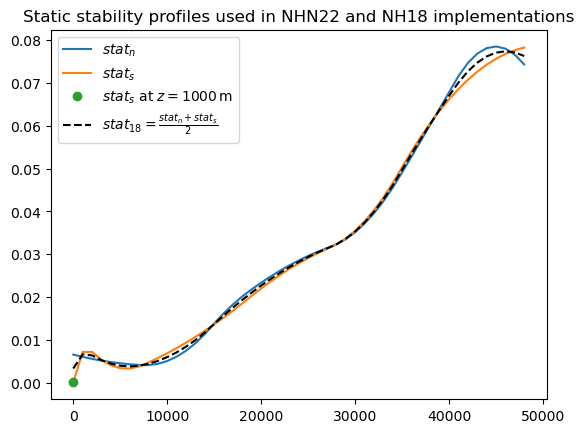

In [32]:
plt.plot(height, stat_n, label=r'$stat_n$')
plt.plot(height, stat_s, label=r'$stat_s$')
plt.plot(height[0], stat_s[0], 'o', label=r'$stat_s$ at $z=1000\,\mathrm{m}$')
plt.plot(height, stat_18, color='k', ls='--',
         label=r'$stat_{18}=\frac{stat_n+stat_s}{2}$')

plt.legend()
plt.title('Static stability profiles used in NHN22 and NH18 implementations')

**Note:** The static stability at $z=1000\,\mathrm{m}$ in the Southern Hemisphere is close to zero.  
This causes the QGPV in the Southern Hemisphere to blow up, which may further lead to instability in the global $q_{\mathrm{ref}}$ when $q_{\max}$ and $q_{\min}$ are computed over the entire domain.

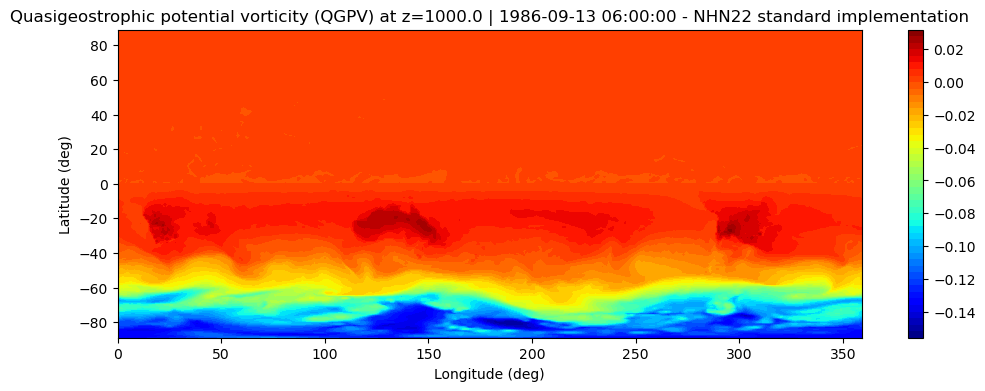

In [33]:
# plot the QGPV fields at z=1000 m from implementations of NHN22. This is the 
plt.figure(figsize=(12,4))
plt.contourf(xlon, ylat[1:-1], qgpv_22[plev_selected, 1:-1, :], 50, cmap='jet')
plt.colorbar()
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.title(f'Quasigeostrophic potential vorticity (QGPV) at z={height[plev_selected]} | {str(tstamp[tstep])} - NHN22 standard implementation')
plt.show()


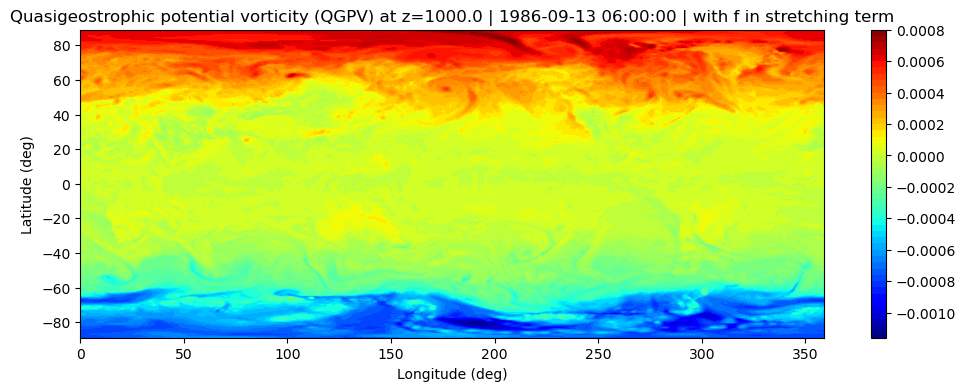

In [34]:
# Plot the QGPV field at z = 1000 m using the NHN22 implementation,
# but with the static stability in the stretching term replaced by
# the global-mean profile (stat_18). This test examines the impact of
# using different background static stability profiles.
#
# The resulting QGPV map now appears well-behaved and closely resembles
# that obtained from the NH18 implementation.
plt.figure(figsize=(12,4))
plt.contourf(xlon, ylat[1:-1], qgpv_22_stat18[plev_selected, 1:-1, :], 50, cmap='jet')
plt.colorbar()
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.title(f'Quasigeostrophic potential vorticity (QGPV) at z={height[plev_selected]} | {str(tstamp[tstep])} | with f in stretching term')
plt.show()


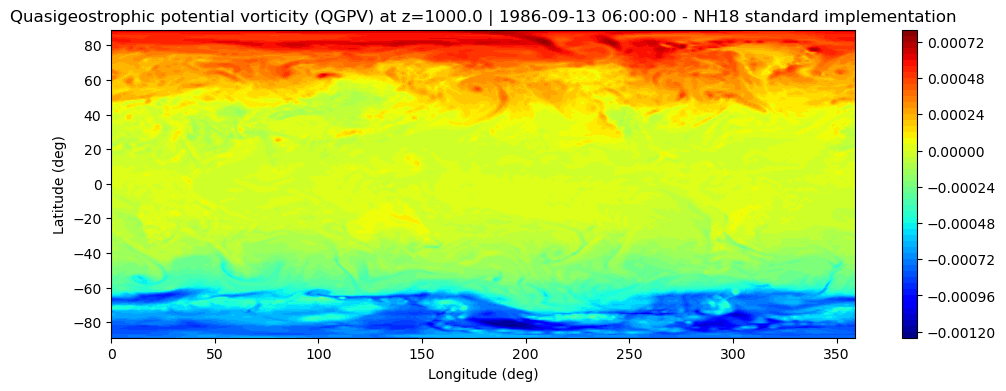

In [35]:
# Plot the QGPV field at z = 1000 m computed using an approximate NH18 implementation.
plt.figure(figsize=(12,4))
plt.contourf(xlon, ylat[1:-1], qgpv_18[plev_selected, 1:-1, :], 50, cmap='jet')
plt.colorbar()
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.title(f'Quasigeostrophic potential vorticity (QGPV) at z={height[plev_selected]} | {str(tstamp[tstep])} - NH18 standard implementation')
plt.show()


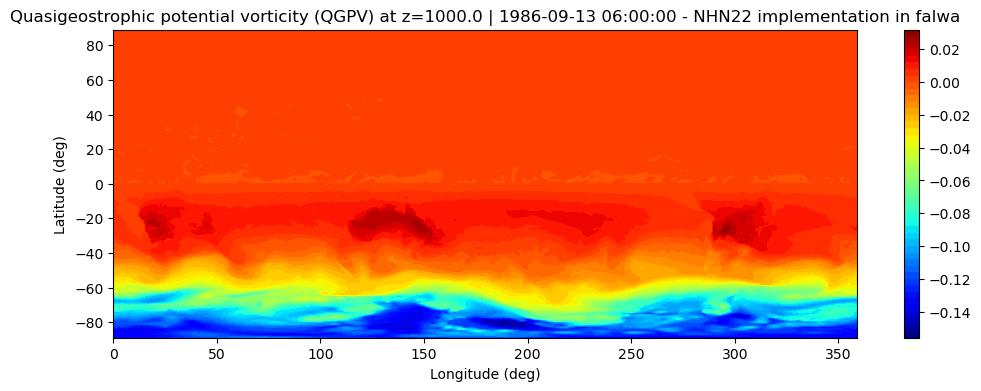

In [36]:
# Plot the QGPV field at z = 1000 m computed using the standardNHN22 implementation with f in the stretching term. 
plt.figure(figsize=(12,4))
plt.contourf(xlon, ylat[1:-1], qgfield_object.qgpv[plev_selected, 1:-1, :], 50, cmap='jet')
plt.colorbar()
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.title(f'Quasigeostrophic potential vorticity (QGPV) at z={height[plev_selected]} | {str(tstamp[tstep])} - NHN22 implementation in falwa')
plt.show()
